In [2]:
%pip install imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 4.9 MB/s eta 0:00:00


In [6]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, color, util, filters, restoration, morphology
from sklearn.decomposition import PCA
import imagehash
from PIL import Image

# Helper to show images
def show(img, title="Image", cmap=None):
    plt.figure(figsize=(4,4))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()


## 1. Image Compression using PCA

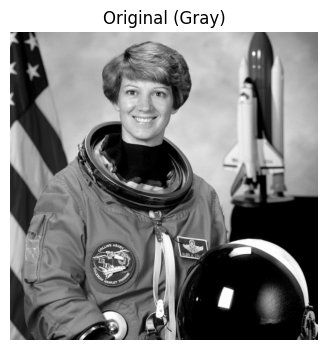

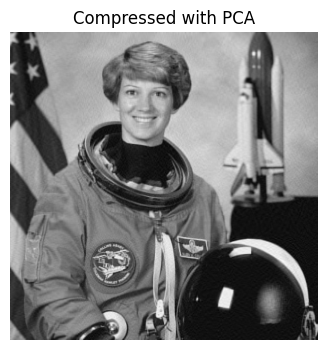

In [32]:

# Load sample image
img = img_as_float(data.astronaut())
img_gray = color.rgb2gray(img)

# Apply PCA compression
X = img_gray.reshape(-1, img_gray.shape[1])
pca = PCA(n_components=100)
X_pca = pca.fit_transform(X)
X_reconstructed = pca.inverse_transform(X_pca)

show(img_gray, "Original (Gray)", cmap="gray")
show(X_reconstructed, "Compressed with PCA", cmap="gray")


## 2. Image Restoration (Denoising)

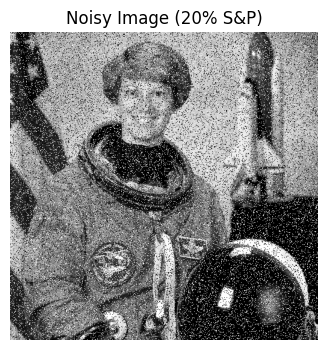

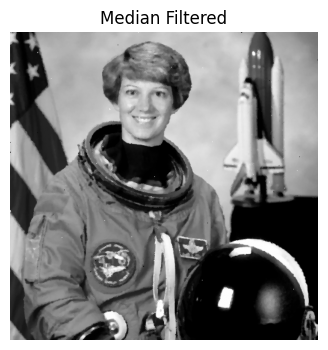

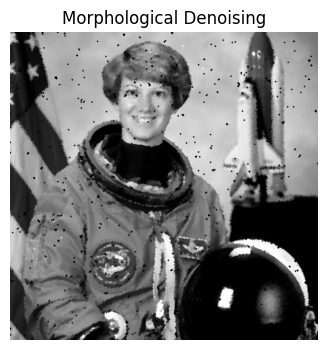

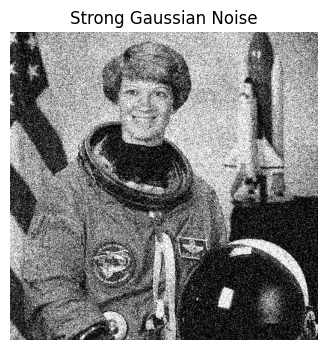

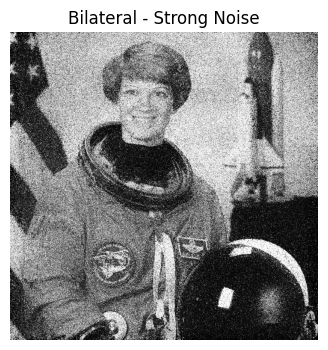

In [19]:
noisy = util.random_noise(img_gray, mode="s&p", amount=0.2)


denoised_median = filters.median(noisy, morphology.disk(2))


opened = morphology.opening(noisy, morphology.disk(1))
denoised_morph = morphology.closing(opened, morphology.disk(1))

denoised_bilateral = restoration.denoise_bilateral(noisy, sigma_color=0.1, sigma_spatial=10)

show(noisy, "Noisy Image (20% S&P)", cmap="gray")
show(denoised_median, "Median Filtered", cmap="gray")
show(denoised_morph, "Morphological Denoising", cmap="gray")


noisy_strong = util.random_noise(img_gray, mode="gaussian", var=0.05)
denoised_bilateral_strong = restoration.denoise_bilateral(
    noisy_strong,
    sigma_color=0.15,
    sigma_spatial=7
)

show(noisy_strong, "Strong Gaussian Noise", cmap="gray")
show(denoised_bilateral_strong, "Bilateral - Strong Noise", cmap="gray")

## 3. Image Segmentation

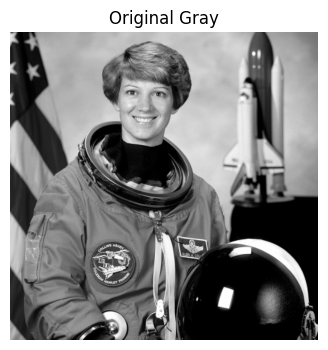

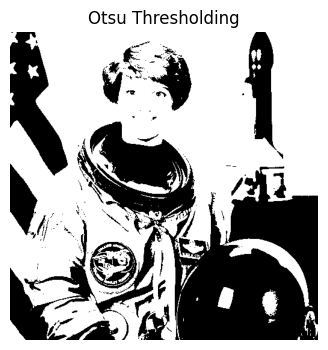

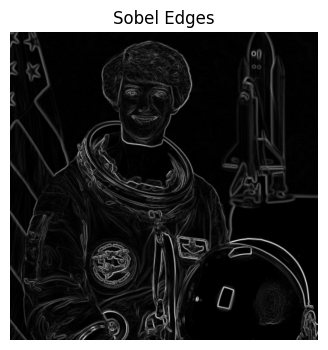

In [9]:

# Thresholding segmentation
thresh = img_gray > filters.threshold_otsu(img_gray)
edges = filters.sobel(img_gray)

show(img_gray, "Original Gray", cmap="gray")
show(thresh, "Otsu Thresholding", cmap="gray")
show(edges, "Sobel Edges", cmap="gray")


## 4. Image Fingerprint Generation (Perceptual Hashing)

In [10]:

pil_img = Image.fromarray((img_gray * 255).astype(np.uint8))
hash_val = imagehash.phash(pil_img)
print("Image fingerprint (pHash):", hash_val)


Image fingerprint (pHash): c2924c5d32bddfc0


## 5. Image Quality Detection (Blurriness)


In [11]:
gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
score = cv2.Laplacian(gray, cv2.CV_64F).var()
print("Blur score (higher = sharper):", score)

Blur score (higher = sharper): 861.4778167539625


## 6. Image Quality Enhancement (Histogram Equalization)


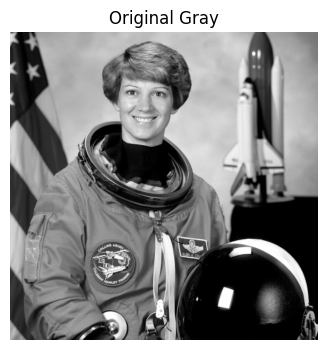

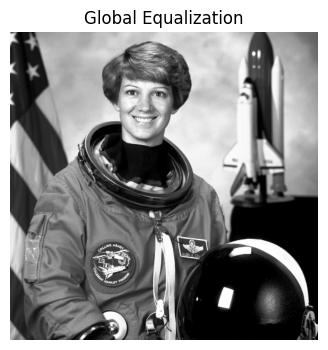

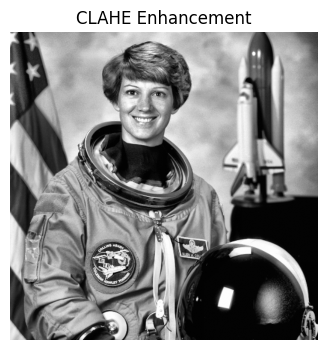

In [20]:
gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

# Global histogram equalization
eq_global = cv2.equalizeHist(gray)

# CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
eq_clahe = clahe.apply(gray)

show(gray, "Original Gray", cmap="gray")
show(eq_global, "Global Equalization", cmap="gray")
show(eq_clahe, "CLAHE Enhancement", cmap="gray")